# Flood Prediction using Machine Learning

This notebook reads the flood dataset, preprocesses it, trains three classification algorithms,
creates confusion matrices and classification reports, compares accuracy, saves the best model as
`flood.pkl`, and generates a standalone `input()`-based testing program.


In [1]:
# !pip install openpyxl

In [2]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

DATASET_PATH = "flood_dataset.xlsx"
OUTPUT_DIR = "flood_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [3]:
# 1. Read dataset
df = pd.read_excel(DATASET_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())
print("\nData types:")
print(df.dtypes)


Dataset shape: (144401, 10)

Columns:
['X', 'Y', 'Slope', 'Curvature ', 'Aspect', 'TWI', 'FA', 'Drainage', 'Rainfall', 'SUSCEP']

First 5 rows:


,X,Y,Slope,Curvature,Aspect,TWI,FA,Drainage,Rainfall,SUSCEP
0,3.909444,7.443056,46.686142,-3.888000e+09,45.000000,-3.250368,147.0,228.8528,101.515616,Very_High
1,3.908611,7.442778,52.151768,1.296000e+09,60.945396,-4.313832,61.0,229.6781,80.409863,Very_High
2,3.908889,7.442778,66.484085,0.000000e+00,67.619865,-8.327622,1.0,230.5920,78.986849,Very_High
3,3.909167,7.442778,58.007183,-2.592000e+09,38.659809,-4.707937,51.0,235.4210,81.953151,Very_High
4,3.909444,7.442778,60.503792,-1.296000e+09,351.869904,-5.985817,15.0,234.4346,85.866027,Very_High



Data types:
X             float64
Y             float64
Slope         float64
Curvature     float64
Aspect        float64
TWI           float64
FA            float64
Drainage      float64
Rainfall      float64
SUSCEP         object
dtype: object


In [4]:
# 2. Preprocessing
TARGET_COLUMN = 'SUSCEP'

df = df.dropna(axis=1, how="all")
df = df.drop_duplicates().reset_index(drop=True)

for col in df.columns:
    if df[col].isna().any():
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

X = df.drop(columns=[TARGET_COLUMN]).copy()
y = df[TARGET_COLUMN].copy()

feature_encoders = {}
for col in X.columns:
    if X[col].dtype == "object" or str(X[col].dtype).startswith("category"):
        enc = LabelEncoder()
        X[col] = enc.fit_transform(X[col].astype(str))
        feature_encoders[col] = enc

target_encoder = None
if y.dtype == "object" or str(y.dtype).startswith("category"):
    target_encoder = LabelEncoder()
    y = pd.Series(target_encoder.fit_transform(y.astype(str)), name=TARGET_COLUMN)

processed_df = X.copy()
processed_df[TARGET_COLUMN] = y
processed_path = os.path.join(OUTPUT_DIR, "flood_processed.csv")
processed_df.to_csv(processed_path, index=False)

print("Processed dataset saved to:", processed_path)
print("Processed shape:", processed_df.shape)
print("Target classes:", sorted(pd.Series(y).unique().tolist()))


Processed dataset saved to: flood_outputs\flood_processed.csv
Processed shape: (144401, 10)
Target classes: [0, 1, 2, 3, 4]


In [5]:
# Train/test split and scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Number of features:", X.shape[1])


Training samples: 115520
Testing samples: 28881
Number of features: 9


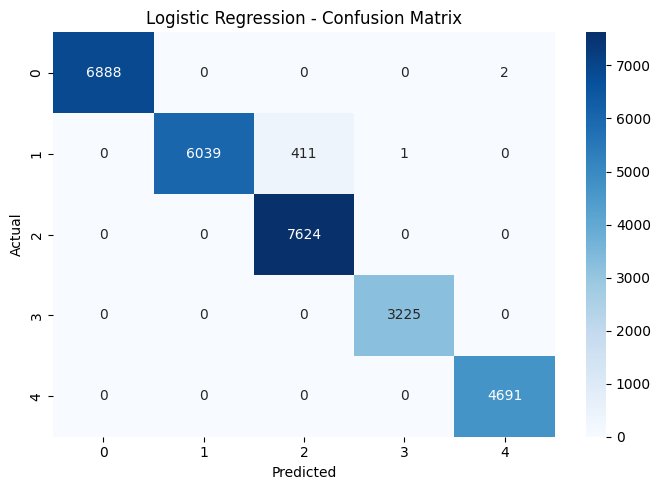

Logistic Regression Accuracy: 0.9857

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6890
           1       1.00      0.94      0.97      6451
           2       0.95      1.00      0.97      7624
           3       1.00      1.00      1.00      3225
           4       1.00      1.00      1.00      4691

    accuracy                           0.99     28881
   macro avg       0.99      0.99      0.99     28881
weighted avg       0.99      0.99      0.99     28881



In [6]:
# Algorithm 1: Logistic Regression
lr_model = LogisticRegression(max_iter=2000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, lr_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "logistic_regression_confusion_matrix.png"), dpi=300)
plt.show()

lr_report = classification_report(y_test, lr_pred, zero_division=0)
print("Logistic Regression Accuracy:", f"{lr_accuracy:.4f}")
print("\nClassification Report:\n", lr_report)
with open(os.path.join(OUTPUT_DIR, "logistic_regression_classification_report.txt"), "w") as f:
    f.write(lr_report)


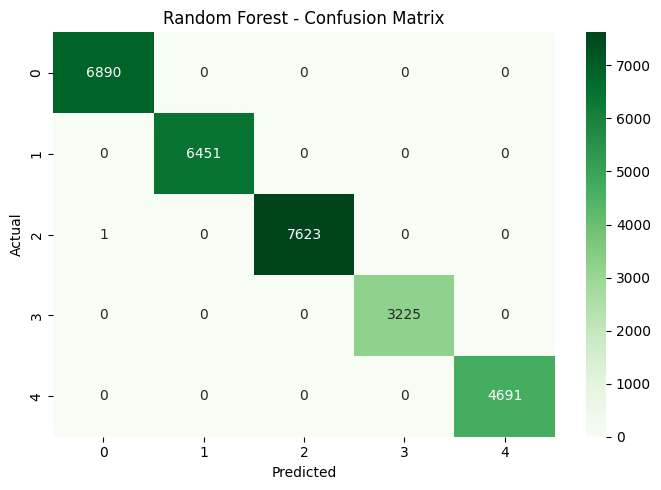

Random Forest Accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6890
           1       1.00      1.00      1.00      6451
           2       1.00      1.00      1.00      7624
           3       1.00      1.00      1.00      3225
           4       1.00      1.00      1.00      4691

    accuracy                           1.00     28881
   macro avg       1.00      1.00      1.00     28881
weighted avg       1.00      1.00      1.00     28881



In [7]:
# Algorithm 2: Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200, random_state=42, class_weight="balanced"
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "random_forest_confusion_matrix.png"), dpi=300)
plt.show()

rf_report = classification_report(y_test, rf_pred, zero_division=0)
print("Random Forest Accuracy:", f"{rf_accuracy:.4f}")
print("\nClassification Report:\n", rf_report)
with open(os.path.join(OUTPUT_DIR, "random_forest_classification_report.txt"), "w") as f:
    f.write(rf_report)


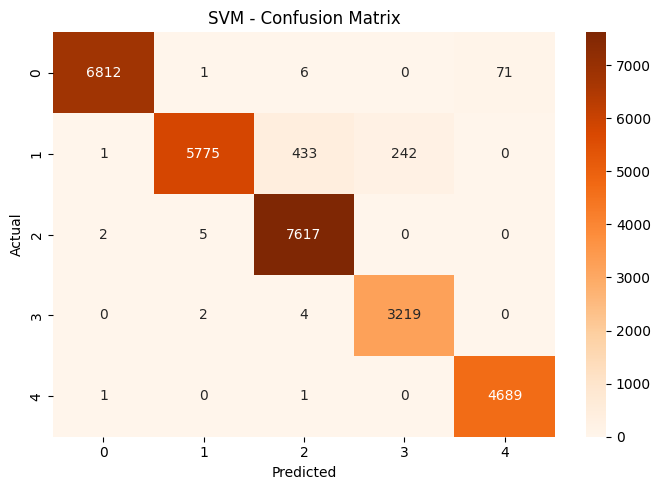

SVM Accuracy: 0.9734

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      6890
           1       1.00      0.90      0.94      6451
           2       0.94      1.00      0.97      7624
           3       0.93      1.00      0.96      3225
           4       0.99      1.00      0.99      4691

    accuracy                           0.97     28881
   macro avg       0.97      0.98      0.97     28881
weighted avg       0.97      0.97      0.97     28881



In [8]:
# Algorithm 3: Support Vector Machine (SVM)
svm_model = SVC(kernel="rbf", probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test, svm_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt="d", cmap="Oranges")
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "svm_confusion_matrix.png"), dpi=300)
plt.show()

svm_report = classification_report(y_test, svm_pred, zero_division=0)
print("SVM Accuracy:", f"{svm_accuracy:.4f}")
print("\nClassification Report:\n", svm_report)
with open(os.path.join(OUTPUT_DIR, "svm_classification_report.txt"), "w") as f:
    f.write(svm_report)


,Algorithm,Accuracy
0,Logistic Regression,0.985665
1,Random Forest,0.999965
2,SVM,0.973373


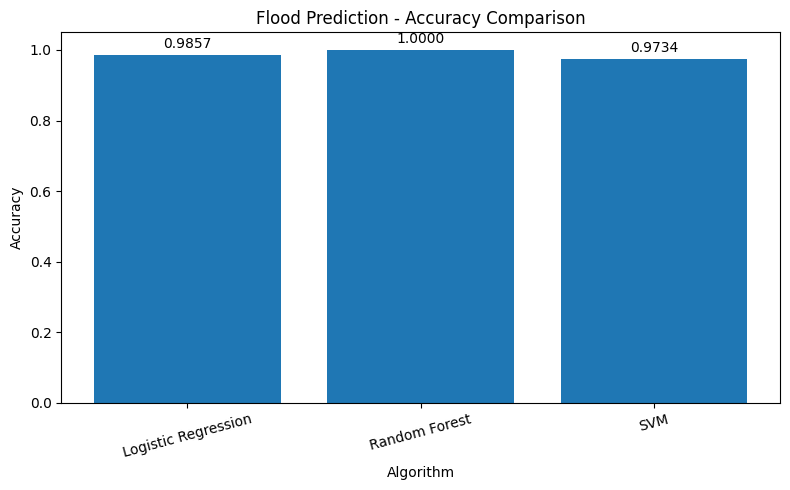

In [9]:
# 4. Accuracy comparison
accuracy_results = pd.DataFrame({
    "Algorithm": ["Logistic Regression", "Random Forest", "SVM"],
    "Accuracy": [lr_accuracy, rf_accuracy, svm_accuracy]
})
display(accuracy_results)

plt.figure(figsize=(8, 5))
bars = plt.bar(accuracy_results["Algorithm"], accuracy_results["Accuracy"])
plt.title("Flood Prediction - Accuracy Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)

for bar, value in zip(bars, accuracy_results["Accuracy"]):
    plt.text(bar.get_x() + bar.get_width()/2, value + 0.02,
             f"{value:.4f}", ha="center")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "accuracy_comparison.png"), dpi=300)
plt.show()


In [10]:
# 5. Store the best model as flood.pkl
models = {
    "Logistic Regression": (lr_model, lr_accuracy, True),
    "Random Forest": (rf_model, rf_accuracy, False),
    "SVM": (svm_model, svm_accuracy, True)
}

best_name = max(models, key=lambda name: models[name][1])
best_model, best_accuracy, uses_scaler = models[best_name]

model_package = {
    "model": best_model,
    "scaler": scaler if uses_scaler else None,
    "uses_scaler": uses_scaler,
    "feature_columns": X.columns.tolist(),
    "feature_encoders": feature_encoders,
    "target_encoder": target_encoder,
    "target_column": TARGET_COLUMN,
    "model_name": best_name,
    "accuracy": best_accuracy
}

joblib.dump(model_package, "flood.pkl")
joblib.dump(model_package, os.path.join(OUTPUT_DIR, "flood.pkl"))

print("Best algorithm:", best_name)
print("Best accuracy:", f"{best_accuracy:.4f}")
print("Saved model: flood.pkl")


Best algorithm: Random Forest
Best accuracy: 1.0000
Saved model: flood.pkl


In [11]:
# 6. Generate standalone testing code
STANDALONE_TEST_CODE = 'import joblib\nimport numpy as np\nimport pandas as pd\n\nMODEL_PATH = "flood.pkl"\npackage = joblib.load(MODEL_PATH)\nmodel = package["model"]\nscaler = package["scaler"]\nuses_scaler = package["uses_scaler"]\nfeature_columns = package["feature_columns"]\nfeature_encoders = package["feature_encoders"]\ntarget_encoder = package["target_encoder"]\n\nprint("\\n===== FLOOD PREDICTION SYSTEM =====")\nvalues = {}\n\nfor feature in feature_columns:\n    while True:\n        try:\n            raw = input(f"Enter {feature}: ")\n            if feature in feature_encoders:\n                values[feature] = raw\n            else:\n                values[feature] = float(raw)\n            break\n        except ValueError:\n            print("Invalid input. Please enter a valid value.")\n\ninput_df = pd.DataFrame([values], columns=feature_columns)\n\nfor feature, encoder in feature_encoders.items():\n    try:\n        input_df[feature] = encoder.transform(input_df[feature].astype(str))\n    except ValueError:\n        print(f"Unknown value for {feature}. Allowed values: {list(encoder.classes_)}")\n        raise SystemExit\n\nif uses_scaler:\n    input_data = scaler.transform(input_df)\nelse:\n    input_data = input_df\n\nprediction = model.predict(input_data)[0]\n\nif target_encoder is not None:\n    result = target_encoder.inverse_transform([int(prediction)])[0]\nelse:\n    result = prediction\n\nprint("\\n===================================")\nprint("        FLOOD PREDICTION RESULT")\nprint("===================================")\nprint("Prediction:", result)\n\nif hasattr(model, "predict_proba"):\n    probabilities = model.predict_proba(input_data)[0]\n    print(f"Confidence: {np.max(probabilities) * 100:.2f}%")\n\nprint("===================================\\n")\n'
with open("standalone_flood_test.py", "w", encoding="utf-8") as f:
    f.write(STANDALONE_TEST_CODE)
print("Generated: standalone_flood_test.py")


Generated: standalone_flood_test.py
